In [37]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [34]:
!python -m spacy download en_core_web_md -qq
!pip install truecase -qq
!pip install -qq gensim
!pip install pyLDAvis -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 53.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.0 MB/s eta 0:00:00


In [35]:
import numpy as np
import pandas as pd
import spacy
import en_core_web_md
import truecase
import nltk
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.model_selection import train_test_split

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
headlines = pd.read_csv('/content/abcnews-date-text.csv')
headlines

,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers
...,...,...
170400,20050617,vline under fire over late trains
170401,20050617,wadeye education funding shortfall questioned
170402,20050617,wallabies boost nts side to play samoa
170403,20050617,water management seen as crucial to saleyards


In [8]:
pd.set_option('display.max_colwidth', None)

In [10]:
sample = headlines.sample(n=10, random_state=111)
sample

,publish_date,headline_text
40575,20030903,england lose gerrard and sinclair
16376,20030509,changes urged to act forest burn offs
67694,20040121,oil company novus announces profit jump
414,20030220,terror weapons pose minimal risk british expert
49071,20031016,bolivian protesters in fatal clash with troops
81166,20040327,port without primus for bombers mission
35151,20030806,us says pneumonia cases in iraq seem sporadic
47683,20031009,iraqs top gym changes name to honour arnie
44494,20030923,roosters re sign walker
35768,20030810,boy dies from gunshot wound


In [11]:
nlp = en_core_web_md.load()

In [16]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
# truecase

sample['truecase_headlines'] = sample['headline_text'].apply(truecase.get_true_case)

In [18]:
sample

,publish_date,headline_text,truecase_headlines
40575,20030903,england lose gerrard and sinclair,England lose Gerrard and Sinclair
16376,20030509,changes urged to act forest burn offs,Changes urged to act forest burn offs
67694,20040121,oil company novus announces profit jump,Oil company Novus ANNOUNCES profit jump
414,20030220,terror weapons pose minimal risk british expert,Terror weapons pose minimal risk British expert
49071,20031016,bolivian protesters in fatal clash with troops,Bolivian protesters in fatal clash with troops
81166,20040327,port without primus for bombers mission,Port without Primus for bombers mission
35151,20030806,us says pneumonia cases in iraq seem sporadic,Us says pneumonia cases in Iraq seem sporadic
47683,20031009,iraqs top gym changes name to honour arnie,Iraqs top gym changes name to honour Arnie
44494,20030923,roosters re sign walker,Roosters re sign Walker
35768,20030810,boy dies from gunshot wound,Boy dies from gunshot wound


In [20]:
test_truecase = np.array(sample.get('truecase_headlines'))
for doc in nlp.pipe(test_truecase):
    print([(ent.text, ent.label_) for ent in doc.ents])

[('England', 'GPE'), ('Gerrard', 'GPE'), ('Sinclair', 'PERSON')]
[]
[]
[('British', 'NORP')]
[('Bolivian', 'NORP')]
[('Primus', 'GPE')]
[('Us', 'GPE'), ('Iraq', 'GPE')]
[('Iraqs', 'ORG'), ('Arnie', 'PERSON')]
[('Walker', 'PERSON')]
[]


In [21]:
test_headlines = np.array(sample.get('headline_text'))
for doc in nlp.pipe(test_headlines):
    print([(ent.text, ent.label_) for ent in doc.ents])

[('england', 'GPE'), ('gerrard', 'GPE'), ('sinclair', 'ORG')]
[]
[]
[('british', 'NORP')]
[('bolivian', 'NORP')]
[('primus', 'GPE')]
[('iraq', 'GPE')]
[('iraqs', 'ORG')]
[]
[]


In [24]:
X_train, X_test = train_test_split(headlines, test_size = .959, random_state=111)

In [28]:
X_train = X_train.reset_index()

In [31]:
# tags to be removed
removal= ['ADV','PRON','CCONJ','PUNCT','PART','DET','ADP','SPACE', 'NUM', 'SYM']

tokens = []
for headline in nlp.pipe(X_train['headline_text']):
  proj_tok = [token.lemma_.lower() for token in headline if token.pos_ not in removal and not token.is_stop and token.is_alpha]
  tokens.append(proj_tok)

In [32]:
X_train['tokens'] = tokens
X_train['tokens']

,tokens
0,"[nrl, foursome, ponder, early, plea]"
1,"[burma, criticise, fail, stop, force, labour]"
2,"[fish, kill, cause, remain, unknown]"
3,"[kimberley, host, domestic, violence, education]"
4,"[worker, vote, ir, change]"
...,...
6981,"[regional, rail, safety, spotlight]"
6982,"[rain, delay, gymkhana]"
6983,"[grampian, blaze, burn]"
6984,"[deny, target, al, jazeera]"


In [38]:
dictionary = Dictionary(X_train['tokens'])
print(dictionary.token2id)

{'early': 0, 'foursome': 1, 'nrl': 2, 'plea': 3, 'ponder': 4, 'burma': 5, 'criticise': 6, 'fail': 7, 'force': 8, 'labour': 9, 'stop': 10, 'cause': 11, 'fish': 12, 'kill': 13, 'remain': 14, 'unknown': 15, 'domestic': 16, 'education': 17, 'host': 18, 'kimberley': 19, 'violence': 20, 'change': 21, 'ir': 22, 'vote': 23, 'worker': 24, 'australian': 25, 'charge': 26, 'day': 27, 'lead': 28, 'lehmann': 29, 'waugh': 30, 'case': 31, 'general': 32, 'iraqi': 33, 'prisoner': 34, 'scrutiny': 35, 'claim': 36, 'green': 37, 'job': 38, 'loss': 39, 'mining': 40, 'reject': 41, 'arrest': 42, 'iraq': 43, 'report': 44, 'saddam': 45, 'unconfirmed': 46, 'afp': 47, 'interference': 48, 'latham': 49, 'political': 50, 'weaken': 51, 'hydro': 52, 'restructure': 53, 'sit': 54, 'union': 55, 'china': 56, 'explosion': 57, 'check': 58, 'perth': 59, 'sar': 60, 'student': 61, 'firm': 62, 'privatised': 63, 'redundancy': 64, 'ta': 65, 'win': 66, 'announce': 67, 'chinese': 68, 'partnership': 69, 'university': 70, 'ballistic':

In [39]:
dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=1000)

In [41]:
corpus = [dictionary.doc2bow(doc) for doc in X_train['tokens']]

In [42]:
lda_model = LdaModel(corpus=corpus, id2word=dictionary, iterations=50, num_topics=10, passes=10)

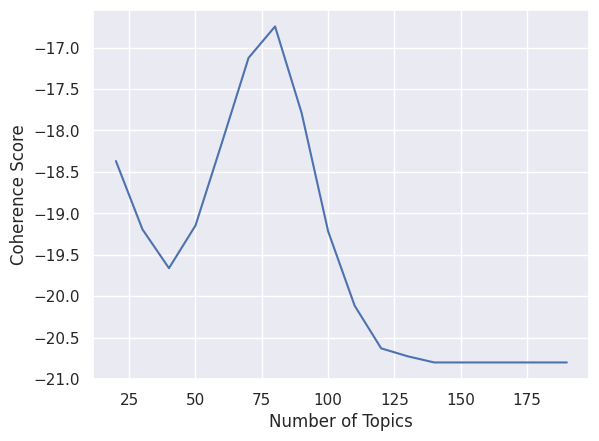

In [46]:
topics = []
score = []
for i in range(20,200,10):
   lda_model = LdaModel(corpus=corpus, id2word=dictionary, iterations=10, num_topics=i, passes=10, random_state=100)
   cm = CoherenceModel(model=lda_model, corpus=corpus, dictionary=dictionary, coherence='u_mass')
   topics.append(i)
   score.append(cm.get_coherence())
_=plt.plot(topics, score)
_=plt.xlabel('Number of Topics')
_=plt.ylabel('Coherence Score')
plt.show()

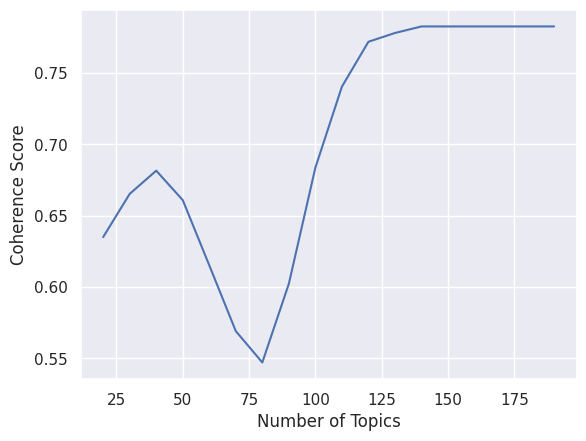

In [47]:
topics = []
score = []
for i in range(20,200,10):
   lda_model = LdaModel(corpus=corpus, id2word=dictionary, iterations=10, num_topics=i, passes=10, random_state=100)
   cm = CoherenceModel(model=lda_model, texts = X_train['tokens'], corpus=corpus, dictionary=dictionary, coherence='c_v')
   topics.append(i)
   score.append(cm.get_coherence())
_=plt.plot(topics, score)
_=plt.xlabel('Number of Topics')
_=plt.ylabel('Coherence Score')
plt.show()

In [48]:
lda_model = LdaModel(corpus=corpus, id2word=dictionary, iterations=100, num_topics=30, passes=100)

In [49]:
lda_model.print_topics(-1)

[(0,
  '0.116*"set" + 0.090*"wa" + 0.070*"concern" + 0.049*"mayor" + 0.048*"lose" + 0.038*"close" + 0.034*"go" + 0.026*"govt" + 0.026*"sex" + 0.025*"condemn"'),
 (1,
  '0.111*"warn" + 0.075*"case" + 0.063*"china" + 0.046*"north" + 0.046*"station" + 0.035*"korea" + 0.034*"study" + 0.033*"move" + 0.033*"state" + 0.031*"funding"'),
 (2,
  '0.137*"fire" + 0.081*"change" + 0.060*"public" + 0.047*"england" + 0.044*"delay" + 0.043*"sa" + 0.040*"return" + 0.039*"bush" + 0.039*"hold" + 0.038*"clash"'),
 (3,
  '0.089*"act" + 0.052*"blast" + 0.048*"injury" + 0.043*"nz" + 0.040*"criticise" + 0.039*"clean" + 0.037*"pm" + 0.036*"focus" + 0.036*"fuel" + 0.033*"crisis"'),
 (4,
  '0.114*"govt" + 0.071*"talk" + 0.065*"consider" + 0.062*"call" + 0.056*"cut" + 0.048*"target" + 0.032*"control" + 0.032*"give" + 0.032*"green" + 0.026*"land"'),
 (5,
  '0.100*"water" + 0.080*"boost" + 0.080*"qld" + 0.065*"work" + 0.046*"hope" + 0.038*"begin" + 0.033*"action" + 0.029*"put" + 0.028*"time" + 0.026*"clear"'),
 (6,

In [50]:
lda_display = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(lda_display)